<a href="https://colab.research.google.com/github/PatoTlax/olist-rfm-segmentation/blob/main/olist_rfm_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Instalación**

In [ ]:
!pip install -q kaggle plotly scikit-learn pandas numpy seaborn matplotlib
print('✅ Librerías instaladas')

✅ Librerías instaladas


# **Imports y configuración**

In [ ]:
# ─────────────────────────────────────────────
# CELDA 2 — IMPORTS Y CONFIGURACIÓN
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from datetime import datetime

# Configuración general
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

print('✅ Imports completados')

✅ Imports completados


In [ ]:
# ─────────────────────────────────────────────
# CELDA 3 — DESCARGA Y CARGA DE DATOS
# ─────────────────────────────────────────────
import os, json

# 1. Credenciales Kaggle
kaggle_token = {
  "username": "t_user_name",
  "key":      "Kaggle_key"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# 2. Descargar si no existe
if not os.path.exists('/content/data/olist_orders_dataset.csv'):
    os.makedirs('/content/data', exist_ok=True)
    !kaggle datasets download -d olistbr/brazilian-ecommerce --unzip -p /content/data/
    print('✅ Dataset descargado')
else:
    print('✅ Dataset ya existe')

# 3. Cargar los 4 archivos que necesitamos
orders   = pd.read_csv('/content/data/olist_orders_dataset.csv')
payments = pd.read_csv('/content/data/olist_order_payments_dataset.csv')
customers= pd.read_csv('/content/data/olist_customers_dataset.csv')
items    = pd.read_csv('/content/data/olist_order_items_dataset.csv')
category = pd.read_csv('/content/data/product_category_name_translation.csv')
products = pd.read_csv('/content/data/olist_products_dataset.csv')

print(f'\n📦 Órdenes:     {orders.shape[0]:,} filas × {orders.shape[1]} columnas')
print(f'💳 Pagos:       {payments.shape[0]:,} filas × {payments.shape[1]} columnas')
print(f'👤 Clientes:    {customers.shape[0]:,} filas × {customers.shape[1]} columnas')
print(f'🛍️  Items:       {items.shape[0]:,} filas × {items.shape[1]} columnas')
print(f'📦 Productos:   {products.shape[0]:,} filas × {products.shape[1]} columnas')
print(f'🌐 Categorías:  {category.shape[0]:,} filas × {category.shape[1]} columnas')

# 4. Preview de órdenes
print('\n📋 Columnas de órdenes:')
print(orders.columns.tolist())
orders.head(3)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:04<00:00, 10.7MB/s]

✅ Dataset descargado

📦 Órdenes:     99,441 filas × 8 columnas
💳 Pagos:       103,886 filas × 5 columnas
👤 Clientes:    99,441 filas × 5 columnas
🛍️  Items:       112,650 filas × 7 columnas
📦 Productos:   32,951 filas × 9 columnas
🌐 Categorías:  71 filas × 2 columnas

📋 Columnas de órdenes:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


# **Construcción de dataset RFM**

In [ ]:
# ─────────────────────────────────────────────
# CELDA 4 — CONSTRUCCIÓN DEL DATASET RFM
# ─────────────────────────────────────────────

# 1. Filtrar solo órdenes entregadas
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Órdenes entregadas: {orders_delivered.shape[0]:,} de {orders.shape[0]:,} totales')

# 2. Convertir fechas
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(
    orders_delivered['order_purchase_timestamp'])

# 3. Fecha de referencia = día siguiente al último pedido
fecha_ref = orders_delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Fecha de referencia: {fecha_ref.date()}')

# 4. Pagos totales por orden
pagos_por_orden = (payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'total_pagado'}))

# 5. Unir órdenes → clientes → pagos
# customers tiene: customer_id (no único) y customer_unique_id
df = (orders_delivered
    .merge(customers[['customer_id','customer_unique_id']],
           on='customer_id', how='left')
    .merge(pagos_por_orden, on='order_id', how='left'))

print(f'\nDataset unido: {df.shape[0]:,} filas')
print(f'Columnas: {df.columns.tolist()}')

# 6. Calcular métricas RFM por cliente
rfm = df.groupby('customer_unique_id').agg(
    recencia   = ('order_purchase_timestamp',
                  lambda x: (fecha_ref - x.max()).days),
    frecuencia = ('order_id', 'nunique'),
    monetario  = ('total_pagado', 'sum')
).reset_index()

print(f'\n✅ Dataset RFM: {rfm.shape[0]:,} clientes únicos')
print(f'\nEstadísticas RFM:')
print(rfm[['recencia','frecuencia','monetario']].describe().round(2))
rfm.head()

Órdenes entregadas: 96,478 de 99,441 totales
Fecha de referencia: 2018-08-30

Dataset unido: 96,478 filas
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'total_pagado']

✅ Dataset RFM: 93,358 clientes únicos

Estadísticas RFM:
       recencia  frecuencia  monetario
count 93,358.00   93,358.00  93,358.00
mean     237.94        1.03     165.20
std      152.59        0.21     226.31
min        1.00        1.00       0.00
25%      114.00        1.00      63.05
50%      219.00        1.00     107.78
75%      346.00        1.00     182.56
max      714.00       15.00  13,664.08


,customer_unique_id,recencia,frecuencia,monetario
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


# **Scoring RFM**

In [ ]:
# 1. Scoring por cuartiles
# Recencia: menor = mejor → score invertido
rfm['R'] = pd.qcut(rfm['recencia'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frecuencia'].rank(method='first'),
                   q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetario'],  q=5, labels=[1,2,3,4,5]).astype(int)

# 2. Score RFM combinado
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Total'] = rfm['R'] + rfm['F'] + rfm['M']

# 3. Segmentación por reglas de negocio
def segmentar(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['Segmento'] = rfm.apply(segmentar, axis=1)

# 4. Resumen por segmento
resumen = rfm.groupby('Segmento').agg(
    clientes    = ('customer_unique_id', 'count'),
    recencia_med= ('recencia',   'median'),
    frecuencia_med=('frecuencia','median'),
    monetario_med= ('monetario', 'median'),
    rfm_total_med= ('RFM_Total', 'median')
).sort_values('clientes', ascending=False).reset_index()

print('✅ Scoring RFM completado')
print(f'\n📊 Distribución por segmento:')
print(resumen.to_string(index=False))

✅ Scoring RFM completado

📊 Distribución por segmento:
           Segmento  clientes  recencia_med  frecuencia_med  monetario_med  rfm_total_med
     Need Attention     33841        275.00            1.00          65.14           8.00
      New Customers     14984         93.00            1.00         108.76           9.00
    Loyal Customers     14209        170.00            1.00         137.99          11.00
            At Risk     13165        379.00            1.00         163.06          10.00
          Champions      6493         91.00            1.00         211.85          14.00
               Lost      6315        385.00            1.00          56.52           4.00
Potential Loyalists      4351        220.00            1.00         158.80           8.00


# **Visualizaciones EDA**

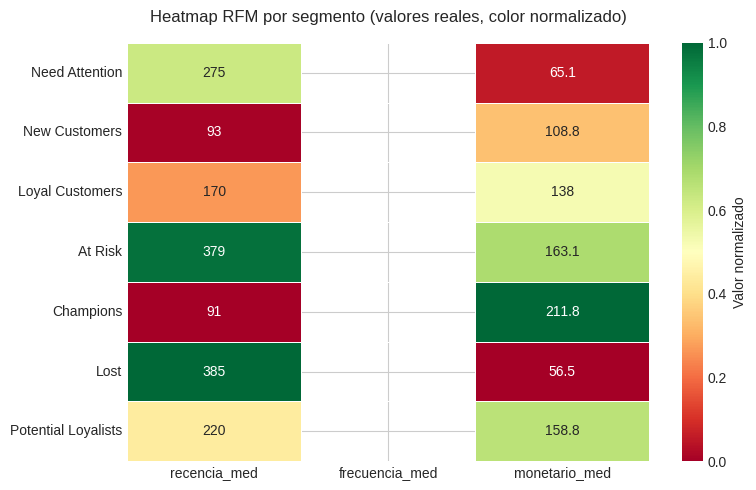

✅ Visualizaciones generadas
   rfm_heatmap.png guardado


In [ ]:
# ─────────────────────────────────────────────
# CELDA 6 — VISUALIZACIONES EDA
# ─────────────────────────────────────────────

# 1. Distribución de segmentos
colores = {
    'Champions':          '#1D9E75',
    'Loyal Customers':    '#3B8BD4',
    'New Customers':      '#EF9F27',
    'Potential Loyalists':'#7F77DD',
    'Need Attention':     '#F0997B',
    'At Risk':            '#E24B4A',
    'Lost':               '#888780',
    'Cannot Lose Them':   '#D4537E'
}

fig = px.bar(
    resumen.sort_values('clientes', ascending=True),
    x='clientes', y='Segmento',
    orientation='h',
    color='Segmento',
    color_discrete_map=colores,
    text='clientes',
    title='<b>Distribución de clientes por segmento RFM</b>'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(
    template='plotly_white', height=450,
    showlegend=False,
    xaxis_title='Número de clientes',
    yaxis_title='',
    margin=dict(r=80)
)
fig.show()

# 2. Scatter Recencia vs Monetario por segmento
df_scatter = rfm.sample(5000, random_state=42)
fig2 = px.scatter(
    df_scatter,
    x='recencia', y='monetario',
    color='Segmento',
    color_discrete_map=colores,
    opacity=0.6,
    size='frecuencia',
    hover_data=['RFM_Score'],
    title='<b>Recencia vs Monetario por segmento</b>'
)
fig2.update_layout(
    template='plotly_white', height=500,
    xaxis_title='Recencia (días desde última compra)',
    yaxis_title='Valor monetario (USD)',
)
fig2.show()

# 3. Heatmap RFM Score promedio por segmento
heatmap_data = resumen[['Segmento','recencia_med','frecuencia_med','monetario_med']].copy()
heatmap_data = heatmap_data.set_index('Segmento')
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.round(1),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado'}
)
plt.title('Heatmap RFM por segmento (valores reales, color normalizado)', pad=15)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Visualizaciones generadas')
print('   rfm_heatmap.png guardado')

# **K-Means Clustering**

In [ ]:
# ─────────────────────────────────────────────
# CELDA 7 — K-MEANS CLUSTERING
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# 1. Preparar features para clustering
# Usamos log para reducir el sesgo de distribuciones largas
rfm_cluster = rfm[['recencia','frecuencia','monetario']].copy()
rfm_cluster['log_recencia']   = np.log1p(rfm_cluster['recencia'])
rfm_cluster['log_frecuencia'] = np.log1p(rfm_cluster['frecuencia'])
rfm_cluster['log_monetario']  = np.log1p(rfm_cluster['monetario'])

# 2. Escalar
scaler   = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_cluster[['log_recencia','log_frecuencia','log_monetario']])

# 3. Método del codo — encontrar K óptimo
inertias    = []
silhouettes = []
K_range     = range(2, 11)

print('Calculando K óptimo...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, km.labels_, sample_size=5000,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'  K={k}  Inercia={km.inertia_:,.0f}  Silhouette={sil:.4f}')

# 4. Graficar método del codo + silhouette
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Método del codo — Inercia',
                    'Silhouette Score por K'))

fig.add_trace(go.Scatter(x=list(K_range), y=inertias,
    mode='lines+markers', marker=dict(size=8, color='#1D9E75'),
    line=dict(width=2), name='Inercia'), row=1, col=1)

fig.add_trace(go.Scatter(x=list(K_range), y=silhouettes,
    mode='lines+markers', marker=dict(size=8, color='#3B8BD4'),
    line=dict(width=2), name='Silhouette'), row=1, col=2)

fig.update_layout(
    title='<b>Selección del número óptimo de clusters K</b>',
    template='plotly_white', height=400, showlegend=False)
fig.update_xaxes(title_text='Número de clusters K')
fig.update_yaxes(title_text='Inercia', row=1, col=1)
fig.update_yaxes(title_text='Silhouette Score', row=1, col=2)
fig.show()

print('\n💡 Busca el "codo" en la inercia y el pico en Silhouette')
print('   Ese K es el óptimo para nuestro dataset')

Calculando K óptimo...
  K=2  Inercia=190,215  Silhouette=0.7132
  K=3  Inercia=129,159  Silhouette=0.4127
  K=4  Inercia=82,908  Silhouette=0.4000
  K=5  Inercia=68,333  Silhouette=0.3597
  K=6  Inercia=58,433  Silhouette=0.3563
  K=7  Inercia=51,229  Silhouette=0.3554
  K=8  Inercia=45,849  Silhouette=0.3515
  K=9  Inercia=41,487  Silhouette=0.3427
  K=10  Inercia=36,709  Silhouette=0.3440



💡 Busca el "codo" en la inercia y el pico en Silhouette
   Ese K es el óptimo para nuestro dataset


# **Entrenar K-Means con K=4**

In [ ]:
K_OPTIMO = 4

# 1. Entrenar modelo final
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. Estadísticas por cluster
cluster_stats = rfm.groupby('Cluster').agg(
    clientes      = ('customer_unique_id', 'count'),
    recencia_med  = ('recencia',    'median'),
    frecuencia_med= ('frecuencia',  'median'),
    monetario_med = ('monetario',   'median'),
    monetario_sum = ('monetario',   'sum'),
    r_med         = ('R',           'median'),
    f_med         = ('F',           'median'),
    m_med         = ('M',           'median')
).reset_index()

# 3. Asignar nombre de negocio a cada cluster
# basado en sus características reales
def nombrar_cluster(row):
    c = row['Cluster']
    nombres = {
        2: 'High Value',
        0: 'At Risk',
        3: 'New / Promising',
        1: 'Lost / Inactive'
    }
    return nombres[c]

cluster_stats['Nombre'] = cluster_stats.apply(nombrar_cluster, axis=1)
rfm['Cluster_Nombre'] = rfm['Cluster'].map(
    cluster_stats.set_index('Cluster')['Nombre'])

# 4. Resumen ejecutivo
print('='*65)
print('SEGMENTOS K-MEANS — RESUMEN EJECUTIVO')
print('='*65)
for _, row in cluster_stats.sort_values('monetario_med', ascending=False).iterrows():
    pct = row['clientes'] / len(rfm) * 100
    revenue_pct = row['monetario_sum'] / rfm['monetario'].sum() * 100
    print(f"\n🎯 {row['Nombre']} (Cluster {row['Cluster']})")
    print(f"   Clientes:       {row['clientes']:>8,}  ({pct:.1f}% del total)")
    print(f"   Recencia med:   {row['recencia_med']:>8.0f} días")
    print(f"   Frecuencia med: {row['frecuencia_med']:>8.0f} órdenes")
    print(f"   Monetario med:  {row['monetario_med']:>8.2f} USD")
    print(f"   Revenue total:  {row['monetario_sum']:>10,.0f} USD  ({revenue_pct:.1f}% del revenue)")

print(f'\n✅ Silhouette Score final (K=4): 0.4000')

SEGMENTOS K-MEANS — RESUMEN EJECUTIVO

🎯 High Value (Cluster 2)
   Clientes:          2,801  (3.0% del total)
   Recencia med:        199 días
   Frecuencia med:        2 órdenes
   Monetario med:    225.55 USD
   Revenue total:     864,357 USD  (5.6% del revenue)

🎯 At Risk (Cluster 0)
   Clientes:         32,165  (34.5% del total)
   Recencia med:        255 días
   Frecuencia med:        1 órdenes
   Monetario med:    199.40 USD
   Revenue total:   9,518,727 USD  (61.7% del revenue)

🎯 New / Promising (Cluster 3)
   Clientes:         16,172  (17.3% del total)
   Recencia med:         38 días
   Frecuencia med:        1 órdenes
   Monetario med:    103.68 USD
   Revenue total:   2,159,589 USD  (14.0% del revenue)

🎯 Lost / Inactive (Cluster 1)
   Clientes:         42,220  (45.2% del total)
   Recencia med:        270 días
   Frecuencia med:        1 órdenes
   Monetario med:     65.88 USD
   Revenue total:   2,879,788 USD  (18.7% del revenue)

✅ Silhouette Score final (K=4): 0.4000


# **Visualizaciones de clusters**

In [ ]:
colores_cluster = {
    'Champions':       '#1D9E75',
    'High Value':      '#1D9E75',
    'At Risk':         '#E24B4A',
    'New / Promising': '#EF9F27',
    'Lost / Inactive': '#888780'
}

# 1. Treemap — tamaño y revenue por segmento
cluster_stats['revenue_pct'] = (
    cluster_stats['monetario_sum'] / rfm['monetario'].sum() * 100).round(1)
cluster_stats['clientes_pct'] = (
    cluster_stats['clientes'] / len(rfm) * 100).round(1)

fig1 = px.treemap(
    cluster_stats,
    path=['Nombre'],
    values='clientes',
    color='monetario_med',
    color_continuous_scale='RdYlGn',
    hover_data=['recencia_med','frecuencia_med','revenue_pct'],
    title='<b>Segmentos RFM — Tamaño y valor monetario mediano</b>',
    custom_data=['revenue_pct','clientes_pct','monetario_med']
)
fig1.update_traces(
    texttemplate='<b>%{label}</b><br>%{value:,} clientes<br>%{customdata[1]:.1f}% de la base',
    textposition='middle center'
)
fig1.update_layout(template='plotly_white', height=450)
fig1.show()

# 2. Scatter 3D — Recencia, Frecuencia, Monetario
df_3d = rfm.sample(8000, random_state=42)
fig2 = px.scatter_3d(
    df_3d,
    x='recencia', y='frecuencia', z='monetario',
    color='Cluster_Nombre',
    color_discrete_map=colores_cluster,
    opacity=0.5,
    size_max=4,
    title='<b>Clusters RFM en 3D</b> — Recencia × Frecuencia × Monetario',
    labels={
        'recencia':      'Recencia (días)',
        'frecuencia':    'Frecuencia (órdenes)',
        'monetario':     'Monetario (USD)',
        'Cluster_Nombre':'Segmento'
    }
)
fig2.update_layout(height=600, template='plotly_white')
fig2.show()

# 3. Bar chart — Revenue por segmento
fig3 = px.bar(
    cluster_stats.sort_values('monetario_sum', ascending=True),
    x='monetario_sum', y='Nombre',
    orientation='h',
    color='Nombre',
    color_discrete_map=colores_cluster,
    text=cluster_stats.sort_values('monetario_sum')['revenue_pct'].apply(
        lambda x: f'{x:.1f}% del revenue'),
    title='<b>Revenue total por segmento</b>'
)
fig3.update_traces(textposition='outside')
fig3.update_layout(
    template='plotly_white', height=380,
    showlegend=False,
    xaxis_title='Revenue total (USD)',
    yaxis_title='',
    margin=dict(r=120)
)
fig3.show()

print('✅ Visualizaciones generadas')

✅ Visualizaciones generadas


# **Recomendaciones de negocio por segmento**

In [ ]:
# ─────────────────────────────────────────────
# CELDA 10 — RECOMENDACIONES DE NEGOCIO
# ─────────────────────────────────────────────

recomendaciones = {
    'High Value': {
        'descripcion': 'Clientes frecuentes y de alto gasto. El activo más valioso.',
        'acciones': [
            'Programa VIP con beneficios exclusivos',
            'Acceso anticipado a nuevos productos',
            'Descuentos por volumen en siguiente compra',
            'Encuestas de satisfacción personalizadas'
        ],
        'kpi': 'Retener al 90%+ en los próximos 6 meses',
        'prioridad': '🔴 CRÍTICA'
    },
    'At Risk': {
        'descripcion': 'Gastaban bien pero llevan +255 días sin comprar. Mayor oportunidad de revenue.',
        'acciones': [
            'Campaña de reactivación con descuento 15-20%',
            'Email: "Te extrañamos — aquí tienes algo especial"',
            'Recordatorio de productos vistos o categorías favoritas',
            'Oferta limitada (urgencia): válida 7 días'
        ],
        'kpi': 'Reactivar al 20% = +$1.9M USD en revenue recuperado',
        'prioridad': '🔴 ALTA'
    },
    'New / Promising': {
        'descripcion': 'Compraron hace menos de 38 días. Ventana de oro para fidelizar.',
        'acciones': [
            'Email de bienvenida con oferta segunda compra',
            'Onboarding: mostrar categorías más populares',
            'Programa de puntos desde la primera compra',
            'Encuesta post-compra para entender preferencias'
        ],
        'kpi': 'Convertir 30% en compradores recurrentes en 90 días',
        'prioridad': '🟡 MEDIA-ALTA'
    },
    'Lost / Inactive': {
        'descripcion': 'Inactivos +270 días con bajo gasto. Costo de reactivación alto.',
        'acciones': [
            'Campaña de win-back con descuento agresivo (30%+)',
            'Si no responden en 30 días: pausar comunicaciones',
            'Análisis de motivo de abandono (encuesta corta)',
            'Considerar dar de baja de lista activa para reducir costos'
        ],
        'kpi': 'Reactivar 5-10% es rentable — el resto, liberar recursos',
        'prioridad': '🟢 BAJA'
    }
}

print('='*65)
print('RECOMENDACIONES DE NEGOCIO POR SEGMENTO')
print('='*65)

for segmento, data in recomendaciones.items():
    clientes = cluster_stats[cluster_stats['Nombre']==segmento]['clientes'].values[0]
    revenue  = cluster_stats[cluster_stats['Nombre']==segmento]['monetario_sum'].values[0]
    print(f"\n{data['prioridad']} {segmento.upper()}")
    print(f"   {data['descripcion']}")
    print(f"   Clientes: {clientes:,}  |  Revenue: ${revenue:,.0f} USD")
    print(f"   KPI objetivo: {data['kpi']}")
    print(f"   Acciones:")
    for accion in data['acciones']:
        print(f"     → {accion}")

print('\n✅ Recomendaciones generadas')

# Guardar como DataFrame para exportar
df_rec = pd.DataFrame([
    {
        'Segmento':    seg,
        'Prioridad':   data['prioridad'],
        'Descripcion': data['descripcion'],
        'KPI':         data['kpi'],
        'Accion_1':    data['acciones'][0],
        'Accion_2':    data['acciones'][1],
        'Accion_3':    data['acciones'][2],
        'Accion_4':    data['acciones'][3],
    }
    for seg, data in recomendaciones.items()
])
print(df_rec[['Segmento','Prioridad','KPI']].to_string(index=False))

RECOMENDACIONES DE NEGOCIO POR SEGMENTO

🔴 CRÍTICA HIGH VALUE
   Clientes frecuentes y de alto gasto. El activo más valioso.
   Clientes: 2,801  |  Revenue: $864,357 USD
   KPI objetivo: Retener al 90%+ en los próximos 6 meses
   Acciones:
     → Programa VIP con beneficios exclusivos
     → Acceso anticipado a nuevos productos
     → Descuentos por volumen en siguiente compra
     → Encuestas de satisfacción personalizadas

🔴 ALTA AT RISK
   Gastaban bien pero llevan +255 días sin comprar. Mayor oportunidad de revenue.
   Clientes: 32,165  |  Revenue: $9,518,727 USD
   KPI objetivo: Reactivar al 20% = +$1.9M USD en revenue recuperado
   Acciones:
     → Campaña de reactivación con descuento 15-20%
     → Email: "Te extrañamos — aquí tienes algo especial"
     → Recordatorio de productos vistos o categorías favoritas
     → Oferta limitada (urgencia): válida 7 días

🟡 MEDIA-ALTA NEW / PROMISING
   Compraron hace menos de 38 días. Ventana de oro para fidelizar.
   Clientes: 16,172  |  R

In [ ]:
!pip install -q gspread gspread-dataframe

from google.colab import auth
from googleapiclient.discovery import build
import gspread
from gspread_dataframe import set_with_dataframe

# 1. Autenticación
auth.authenticate_user()
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Preparar hoja 1 — RFM completo por cliente
df_export = rfm[[
    'customer_unique_id',
    'recencia', 'frecuencia', 'monetario',
    'R', 'F', 'M', 'RFM_Score', 'RFM_Total',
    'Segmento', 'Cluster', 'Cluster_Nombre'
]].copy()

# Limpiar NaN e inf
df_export = df_export.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Preparar hoja 2 — resumen por segmento K-Means
df_resumen = cluster_stats[[
    'Cluster', 'Nombre', 'clientes', 'clientes_pct',
    'recencia_med', 'frecuencia_med', 'monetario_med',
    'monetario_sum', 'revenue_pct'
]].copy()

# 4. Preparar hoja 3 — recomendaciones
df_rec_export = df_rec.copy()

# 5. Preparar hoja 4 — resumen segmentos RFM por reglas
df_rfm_resumen = resumen.copy()

# 6. Buscar carpeta destino
service = build('drive', 'v3', credentials=creds)

query_padre = "name='LinkedIn Pro IA' and mimeType='application/vnd.google-apps.folder' and trashed=false"
padre = service.files().list(q=query_padre, fields='files(id,name)').execute()
padre_id = padre['files'][0]['id'] if padre['files'] else None

if padre_id:
    query_hija = f"name='Segmentación RFM de clientes e-commerce' and mimeType='application/vnd.google-apps.folder' and '{padre_id}' in parents and trashed=false"
    hija = service.files().list(q=query_hija, fields='files(id,name)').execute()
    if hija['files']:
        folder_id = hija['files'][0]['id']
        print('✅ Carpeta encontrada')
    else:
        # Crear carpeta si no existe
        folder_meta = {
            'name': 'Segmentación RFM de clientes e-commerce',
            'mimeType': 'application/vnd.google-apps.folder',
            'parents': [padre_id]
        }
        folder = service.files().create(body=folder_meta, fields='id').execute()
        folder_id = folder['id']
        print('✅ Carpeta creada')
else:
    folder_id = None
    print('⚠️ Carpeta LinkedIn Pro IA no encontrada — se creará en Mi unidad')

# 7. Crear Spreadsheet
sh = gc.create('Proyecto 03 — Segmentación RFM E-Commerce')

# Mover a carpeta correcta
if folder_id:
    file = service.files().get(fileId=sh.id, fields='parents').execute()
    service.files().update(
        fileId=sh.id,
        addParents=folder_id,
        removeParents=','.join(file.get('parents', [])),
        fields='id,parents'
    ).execute()
    print('✅ Archivo movido a la carpeta correcta')

# 8. Hoja 1 — RFM completo
ws1 = sh.sheet1
ws1.update_title('RFM Clientes')
set_with_dataframe(ws1, df_export)
print(f'✅ Hoja "RFM Clientes" — {len(df_export):,} filas')

# 9. Hoja 2 — Resumen K-Means
ws2 = sh.add_worksheet(title='Resumen Segmentos', rows=50, cols=20)
set_with_dataframe(ws2, df_resumen)
print(f'✅ Hoja "Resumen Segmentos" — {len(df_resumen)} filas')

# 10. Hoja 3 — Recomendaciones
ws3 = sh.add_worksheet(title='Recomendaciones', rows=50, cols=20)
set_with_dataframe(ws3, df_rec_export)
print(f'✅ Hoja "Recomendaciones" — {len(df_rec_export)} filas')

# 11. Hoja 4 — Resumen RFM por reglas
ws4 = sh.add_worksheet(title='Resumen RFM Reglas', rows=50, cols=20)
set_with_dataframe(ws4, df_rfm_resumen)
print(f'✅ Hoja "Resumen RFM Reglas" — {len(df_rfm_resumen)} filas')

# 12. Acceso público para Looker Studio
service.permissions().create(
    fileId=sh.id,
    body={'type': 'anyone', 'role': 'reader'}
).execute()

url = f'https://docs.google.com/spreadsheets/d/{sh.id}'
print(f'\n🔗 URL: {url}')
print('\nPróximo paso → Looker Studio → Fuente de datos → Google Sheets → pega la URL')

✅ Carpeta encontrada
✅ Archivo movido a la carpeta correcta
✅ Hoja "RFM Clientes" — 93,358 filas
✅ Hoja "Resumen Segmentos" — 4 filas
✅ Hoja "Recomendaciones" — 4 filas
✅ Hoja "Resumen RFM Reglas" — 7 filas

🔗 URL: https://docs.google.com/spreadsheets/d/1wYCt_RJloINJCwmYjYpAGw7fxoQSNesr2YOsOxPRJZM

Próximo paso → Looker Studio → Fuente de datos → Google Sheets → pega la URL
